# Test 2b - Merge, Aggregate, Visualize

## Introduction

This problem tests your ability to merge, aggregate, and visualize data.
You'll work with realistic business data to answer questions about product profitability.

Before submitting, ensure your notebook:

- Includes your verification info (Banner ID and code) as the first cell
- Runs completely with "Kernel → Restart & Run All"
- Shows your work (don't just print final answers)
- Includes your interpretation responses at the end

## Dataset: Bean & Brew Coffee Shop

You've been hired to analyze sales data for Bean & Brew, a local coffee shop chain with three locations. The owner wants to understand which products are most profitable and how profitability varies across locations.

There are two data files:

- `sales.csv` - Individual transaction records
  - `transaction_id`: Unique transaction identifier
  - `timestamp`: Date and time of purchase (format: 'YYYY-MM-DD HH:MM:SS')
  - `location`: Store location ('Downtown', 'Campus', 'Suburb')
  - `product_id`: Product identifier (links to products table)
  - `quantity`: Number of units sold
  - `revenue`: Total revenue from transaction
  - `payment_method`: Payment type ('Cash', 'Credit', 'Mobile')
  - `loyalty_member`: Boolean indicating if customer is loyalty program member
- `products.csv` - Product catalog
  - `product_id`: Unique product identifier
  - `name`: Product name
  - `category`: Product category ('Coffee', 'Tea', 'Pastry', 'Sandwich')
  - `cost`: Cost to make/acquire one unit (for profit calculation)

The dataset contains two weeks of sales data (approximately 3,000 transactions) across 18 products. It includes both regular and premium items in each category.

We are interested in learning which product categories generate the most profit, and how does profitability vary across locations? Complete the following tasks to answer those questions and more.

## Scoring

Total: 30 points (+ 5 bonus)

- Tasks 1-6: 18 points
- Interpretation (Questions 1-4): 12 points
- Bonus: 5 points (optional)

## Generate Your Dataset

Before starting the analysis, you need to generate your unique dataset using your Banner ID.

1. Open a terminal in the folder containing `generate_test2b_data.py`
2. Activate your conda virtual environment
3. Run: `python generate_test2b_data.py`
4. Enter your 9-digit Banner ID when prompted (you'll enter it twice to confirm)

The script will create two files in the `data/` folder:

- `data/products.csv` - Product catalog
- `data/sales.csv` - Transaction records

Important: At the end, the script displays a verification block like this:

```
======================================================================
DATA VERIFICATION INFORMATION
======================================================================
banner id:          904123456
verification code:  5e0dXXXXXXXX
======================================================================
```

Copy the banner id and verification code lines and paste them into the cell below. This is required for submission.

```
banner id:          904353569
verification code:  9aaddb7b15db

```

## Setup: Load the Data

Run the cell below to load the data. The code is provided for you.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data (provided)
sales = pd.read_csv('data/sales.csv', parse_dates=['timestamp'])
products = pd.read_csv('data/products.csv')

print(f"Sales: {len(sales)} transactions")
print(f"Products: {len(products)} items in catalog")
print()
print("Sales preview:")
sales.head()

Sales: 2699 transactions
Products: 18 items in catalog

Sales preview:


,transaction_id,timestamp,location,product_id,quantity,revenue,payment_method,loyalty_member
0,1002,2025-11-17 06:04:00,Campus,105,1.0,3.69,Cash,False
1,1003,2025-11-17 06:07:00,Downtown,105,1.0,3.99,Credit,False
2,1001,2025-11-17 06:33:00,Campus,108,1.0,2.32,Mobile,False
3,1000,2025-11-17 06:34:00,Campus,114,1.0,4.37,Mobile,True
4,1017,2025-11-17 07:04:00,Suburb,113,1.0,3.65,Mobile,True


In [11]:
# Products catalog
products

,product_id,name,category,cost
0,101,Espresso,Coffee,1.2
1,102,Cappuccino,Coffee,1.8
2,103,Latte,Coffee,1.9
3,104,Americano,Coffee,1.0
4,105,Cold Brew,Coffee,1.5
5,106,Nitro Cold Brew,Coffee,2.5
6,107,Green Tea,Tea,0.8
7,108,Chai Latte,Tea,1.2
8,109,Herbal Tea,Tea,0.7
9,110,Premium Matcha,Tea,2.2


## Task 1: Data Quality Check

Investigate the sales data quality and coverage. Your code should answer the following questions:

1. How many missing values are in each column?
2. How many unique product IDs appear in the sales data? Compare this to the catalog size.
3. What is the date range (earliest and latest transaction)?

### Your Code

In [13]:
# Task 1: use isna(), nunique(), min/max on timestamp

#1 missing values are in each column
print("Missing values per column:")
print(sales.isna().sum())

#2 unique product IDs in sales data
print(f"\nUnique product IDs in the sales data: {sales['product_id'].nunique()}")
print(f"Products on catalog: {products['product_id'].nunique()}")
print("There is a discrepancy between the amount of products on the catalog and the amount of unique IDs of the products that have been sold. There are 3 product IDs not registered on the catalog.")

#3 date range
print("\nDate range:")
print(f"Earliest transaction: {sales['timestamp'].min()}")
print(f"Latest transaction: {sales['timestamp'].max()}")
print(f"Date range: {sales['timestamp'].max()-sales['timestamp'].min()}")

Missing values per column:
transaction_id    0
timestamp         0
location          0
product_id        0
quantity          6
revenue           3
payment_method    0
loyalty_member    0
dtype: int64

Unique product IDs in the sales data: 21
Products on catalog: 18
There is a discrepancy between the amount of products on the catalog and the amount of unique IDs of the products that have been sold. There are 3 product IDs not registered on the catalog.

Date range:
Earliest transaction: 2025-11-17 06:04:00
Latest transaction: 2025-11-30 21:16:00
Date range: 13 days 15:12:00


## Task 2: Merge Sales with Products

Merge the sales and products DataFrames to add product information (name, category, cost) to each transaction.

### Your Code

In [14]:
# Task 2: use pd.merge() with appropriate join type
sales_merged = pd.merge(sales, products, on='product_id', how='left')

# I print the first five rows to verify that the merge was applied.
sales_merged.head()

,transaction_id,timestamp,location,product_id,quantity,revenue,payment_method,loyalty_member,name,category,cost
0,1002,2025-11-17 06:04:00,Campus,105,1.0,3.69,Cash,False,Cold Brew,Coffee,1.5
1,1003,2025-11-17 06:07:00,Downtown,105,1.0,3.99,Credit,False,Cold Brew,Coffee,1.5
2,1001,2025-11-17 06:33:00,Campus,108,1.0,2.32,Mobile,False,Chai Latte,Tea,1.2
3,1000,2025-11-17 06:34:00,Campus,114,1.0,4.37,Mobile,True,Cinnamon Roll,Pastry,1.4
4,1017,2025-11-17 07:04:00,Suburb,113,1.0,3.65,Mobile,True,Scone,Pastry,1.1


## Task 3: Verify the Merge


After merging, verify that the merge worked correctly:

1. Compare the shape of the merged DataFrame to the original sales data
2. Check if any rows have missing values in the product columns (name, category, cost)
3. If there are missing values, identify which product_id(s) are causing the problem

### Your Code

In [15]:
# Task 3: check shape, isna() on product columns, filter to find problem IDs
#1 Comparing shapes of merged DF and original
print(f"Shape of original sales dataframe: {sales.shape}")
print(f"Shape of the merged dataframe: {sales_merged.shape}")
print("We can see that the number of rows has not been affected, but the number of columns has increased with 3 new columns, as expected (name, category, cost)")
print()

#2 Missing values in any rows in the product columns
print(f"Missing values in the name column: {sales_merged['name'].isna().sum()}")
print(f"Missing values in the category column: {sales_merged['category'].isna().sum()}")
print(f"Missing values in the cost column: {sales_merged['cost'].isna().sum()}")
print()

#3 product IDs of missing values
#To find the IDs of the missing values I search for NaN values on the name, category and cost columns, apply a mask to the dafaframe and extract the unique IDs
missing_values_ids = (sales_merged[sales_merged[['name','category','cost']].isna().any(axis=1)]['product_id']).unique()  #I asked chatGPT about a way to improve this part of code and I learned about .any(axis=1) 
print(f"The ID's of the products missing some values are: {missing_values_ids}")
print("We can see that the missing values correspont to 3 product ids that are not registered in the product catalog.")
print("This is realted to the discrepancy between the amount of products on the catalog and the amount of unique IDs of the products that have been sold.")


Shape of original sales dataframe: (2699, 8)
Shape of the merged dataframe: (2699, 11)
We can see that the number of rows has not been affected, but the number of columns has increased with 3 new columns, as expected (name, category, cost)

Missing values in the name column: 11
Missing values in the category column: 11
Missing values in the cost column: 11

The ID's of the products missing some values are: [200 201 199]
We can see that the missing values correspont to 3 product ids that are not registered in the product catalog.
This is realted to the discrepancy between the amount of products on the catalog and the amount of unique IDs of the products that have been sold.


## Task 4: Profit by Category

First, calculate profit for each transaction: `profit = revenue - (cost × quantity)`

Then summarize profitability by product category. Your code should return a table that shows both total profit and number of transactions for each category. Sort it by total profit (highest first).

### Your Code

In [16]:
# Task 4: create profit column, then groupby with .agg()
sales_merged['profit'] = sales_merged['revenue'] - sales_merged['cost']*sales_merged['quantity']

category_profit_and_count = (sales_merged 
    .groupby('category')
    .agg( total_profit=('profit', 'sum'), transaction_count=('transaction_id', 'count'))
    .sort_values('total_profit', ascending=False))                             

print(category_profit_and_count)
print()
print(f"On the table above we can see that the number of transactions for all categories adds to: {sales_merged.groupby('category', observed=False).size().sum()}.")
print(f"However, from the size of the original data we know that there are {sales.shape[0]} observations. Those 11 missing observations are the ones missing that were identifies on Task 3.")


          total_profit  transaction_count
category                                 
Sandwich       4232.32                605
Coffee         2369.05                969
Pastry         1517.14                524
Tea             928.72                590

On the table above we can see that the number of transactions for all categories adds to: 2688.
However, from the size of the original data we know that there are 2699 observations. Those 11 missing observations are the ones missing that were identifies on Task 3.


## Task 5: Profit by Category and Location

Analyze how profitability varies by both category and location. Your code should produce a table that shows the following for every combination of category and location:

- Total profit
- Average profit per transaction
- Number of transactions

Display the results as a flat table (i.e., without a nested/hierarchical index).

### Your Code

In [17]:
# Task 5: groupby multiple columns, .agg() with dict, reset_index()

#Total profit
category_location = (sales_merged
    .groupby(['category','location'],observed=False)
    .agg(
        total_profit=('profit','sum'),
        average_profit=('profit','mean'),
        transaction_count=('transaction_id','count'))
                    .reset_index())

print(category_location)





    category  location  total_profit  average_profit  transaction_count
0     Coffee    Campus       1118.49        2.086735                537
1     Coffee  Downtown       1043.59        3.007464                347
2     Coffee    Suburb        206.97        2.434941                 85
3     Pastry    Campus        563.15        2.469956                230
4     Pastry  Downtown        613.66        3.547168                174
5     Pastry    Suburb        340.33        2.859916                120
6   Sandwich    Campus        755.25        5.318662                142
7   Sandwich  Downtown       2524.35        7.988449                318
8   Sandwich    Suburb        952.72        6.570483                145
9        Tea    Campus        231.22        1.418528                163
10       Tea  Downtown        315.35        1.751944                180
11       Tea    Suburb        382.15        1.559796                247


## Task 6: Visualize Category Profitability

Create a bar chart showing total profit by product category. Use seaborn and ensure that the result:

- Has clearly labeled categories
- Includes a descriptive title
- Makes it clear which category is most/least profitable

### Your Code

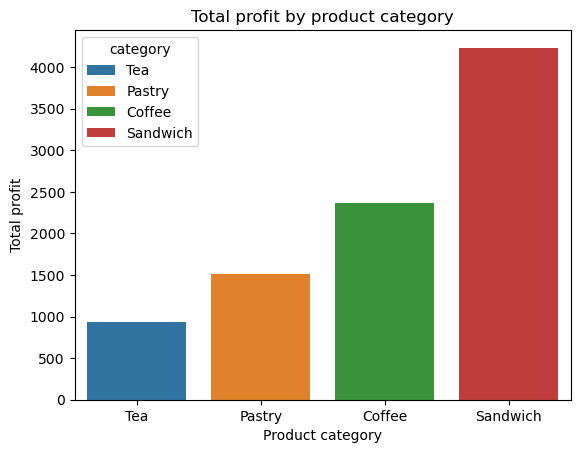

In [18]:
# Task 6: use sns.barplot() with aggregated data

profit_by_category = sales_merged.groupby('category')['profit'].sum().reset_index().sort_values('profit')

sns.barplot(data=profit_by_category, x="category",y="profit", hue="category", legend='full')
plt.title('Total profit by product category')
plt.xlabel('Product category')
plt.ylabel('Total profit')
plt.show()


## Interpretation

Concisely answer the following questions based on your analysis.


1. What might go wrong if you did not verify the merge in Task 3 before proceeding with the analysis?
2. In Tasks 4 and 5, you aggregated data at different levels of detail (by category, then by category and location). How did this change what you could learn from the data?
3. Reflect on the patterns you discovered in your analysis. What valuable insights did your work generate?
4. The coffee shop owner asks: "Based on your analysis, what's the single most important thing I should do to improve profitability?" Provide a specific, actionable recommendation. Justify your recommendation with evidence from your analysis (include specific numbers from your results). Also, suggest additional analysis that you feel might be worthwhile.

### Your Answers

1. If I hadn't verified the merge in Task 3 the subsequent analysis could have been wrong due to a variety of reasons. For example, if I had done the merge incorreclty by filling the product catalog instead of the sales I would have lost many rows of information. If I hadn't checked for missing data then I probably wouldn't have noticed that there were some sales entries with product IDs that are not registered in the product catalog. Failing to realize that these is missing data could have led to confussion in the Profit by Category analysis.

2. By aggregating the data at two levels (category and location) I can sort it based on the value of two different variables. This allowed me to understand more deeply since I can analyze the profitability not only by category, but also by location. I can therefore see how profitable are different products at the same location, and how profitable the same product is at different locations.

3. Based on this analysis we can conclude that, in terms of total profit, sandwiches are the most profitable product, followed by coffee, then pastry, and finally tea. In addition, we know that the most profitable products by location are coffee on campus with a total profit of 1118.49, Sandwiches on Downtown with a total profit of 2524.35, and sandwitches on the suburbs with a total profit of 952.72.
Furthermore, we can look at the most profitable location for every product: campus for coffee, downtown for pastry and sandwich, and suburbs for tea.

4.  Based on the data we can conclude that sandwiches are the most profitable products, since their total profit (4232.32) is almost twice as much as the second most probitable product, coffee (2369.05). This profitability is specially higher in Downtown, where transactions reach 318 for sandwiches, while transactions for pastries and tea only reach 174 and 180 respectively. Therefore, I would recommend offering a special deal that sells sandwiches with tea or pasty, to leverage teh popularity of this product on this specific location.  I would suggest analyzing the transactions and profit based on the time of the day (morning, afternoon, and evening) to understand customer behavior and peak hours. This information could be used to adjust the working hours of the employees and to prepare products before peak hours.

## Bonus: Time-Based Analysis (Optional)

For extra credit, investigate a time-based question of your choosing. Examples of questions you could explore include:

- Do sales patterns differ between weekdays and weekends?
- Which hours are busiest at each location?
- Is there a day of the week that stands out for profitability?

For full credit you must:

- State your question clearly
- Show your analysis code
- Summarize what you found in 2-3 sentences

  day_of_week   profit
3      Sunday   679.56
2    Saturday   755.58
5     Tuesday  1396.94
6   Wednesday  1397.47
1      Monday  1421.56
4    Thursday  1473.35
0      Friday  1922.77
Average profit per day: 1292.46


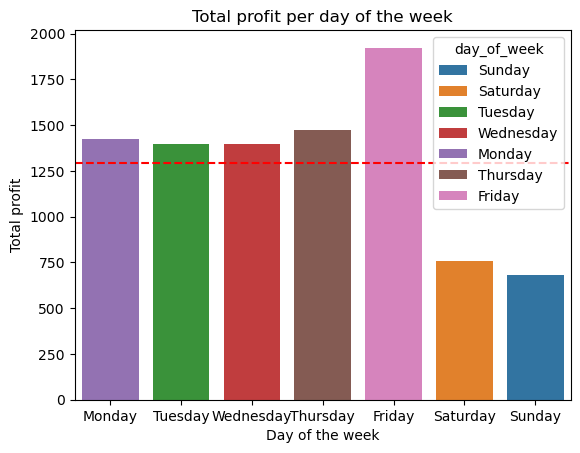

In [19]:
# Bonus: Your time-based analysis here
#add a column to sales dataframe indicating the day of the week.
sales_merged['day_of_week'] = sales_merged['timestamp'].dt.day_name()

#Profit per day of the week
profit_per_day = sales_merged.groupby('day_of_week')['profit'].sum().reset_index().sort_values('profit')
print(profit_per_day)

avg_profit_day = profit_per_day['profit'].mean()
print(f"Average profit per day: {avg_profit_day:.2f}")
#bar chart indicating profit per day to better visualize the data
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

sns.barplot(data=profit_per_day, x="day_of_week",y="profit", hue="day_of_week", legend='full', order=day_order)
plt.title('Total profit per day of the week')
plt.xlabel('Day of the week')
plt.ylabel('Total profit')
plt.axhline(y=avg_profit_day, color='red', linestyle='--', label='Average profit') # reference line
plt.show()


### Your Findings

*Bonus findings here (state your question and what you discovered)*
We want to investigate whether there is a day in which profitability is higher than the rest of the days of the week. To do so we will analyze the profit each day of the week.
Thansk to this analysis we have discovered that Friday is the most profitable day with a total profit of 1922,77. This exceeds the average profit per day by more than 600. Moreover, we can observe that weekend days are the least profitable days of the week, with a total profit of 755,58 on Saturday and 679,56 on Sundays.

## Submission

Ensure your notebook:

- Has the verification block (Banner ID and code) as the first cell
- Runs completely from top to bottom without errors
- Shows all task outputs clearly
- Includes all interpretation responses
- Is saved and committed to your repository

Follow the submission instructions on Canvas to submit your work.